# Gridiron Brief
## AI-Powered Fantasy Football League Chat Summarization

**Project Stage:** Final Project  
**Project Type:** Large Language Model / Dialogue Summarization  
**Dataset:** SAMSum  
**Final Architecture:** Warm-started BERT-to-BERT encoder-decoder fine-tuned for dialogue summarization

### Bottom Line Up Front

Gridiron Brief is a proof-of-concept system for condensing active fantasy football league chats into short, readable summaries. The final project preserves the required BERT-based encoder-decoder architecture while incorporating peer feedback that generation quality may improve when the model begins from a checkpoint already trained for summarization.

The final workflow includes data-quality review, split-leakage prevention, token-length analysis, transformer fine-tuning, validation-based generation tuning, held-out ROUGE evaluation, qualitative factuality review, fantasy-football domain testing, and model save/reload verification.


# 1. Business Understanding

## Business Problem

Fantasy football leagues can generate dozens or hundreds of group-chat messages involving trades, waiver claims, player injuries, lineup decisions, league rules, and matchup results. Important information may become buried among jokes, reactions, and unrelated discussion.

**Gridiron Brief** is intended to reduce this catch-up burden by transforming a lengthy multi-speaker conversation into a concise natural-language summary of the major topics, actions, and decisions.

## Stakeholder

The primary stakeholder is the product team for a messaging or fantasy-sports platform seeking to improve the experience of users returning to active league conversations.

## Business Objective

Reduce the time and cognitive effort required to catch up on active group chats while preserving the information most relevant to league participation.

## Machine-Learning Objective

Fine-tune a pre-trained BERT encoder-decoder model on SAMSum so that it can generate concise abstractive summaries of unseen dialogue.

## Evaluation Plan

The primary quantitative metrics will be **ROUGE-1, ROUGE-2, and ROUGE-L**. Quantitative evaluation will be supplemented with qualitative review for factual accuracy, speaker attribution, omissions, repetition, hallucination, fluency, and conciseness.

## Initial Success Targets

| Measure | Target |
|---|---:|
| ROUGE-1 | ≥ 35 |
| ROUGE-2 | ≥ 12 |
| ROUGE-L | ≥ 32 |
| Human usefulness rating | ≥ 4.0 / 5 |
| Major factual-error-free summaries | ≥ 85% |

## Scope

The project focuses on dialogue summarization. Player projections, trade recommendations, live injury feeds, and predictive sports analytics are outside the MVP scope.

### Central Research Question

> **Can a pre-trained BERT encoder-decoder model convert a lengthy group conversation into a concise, useful summary?**


# 2. Data Understanding

The SAMSum corpus contains messenger-style conversations paired with human-written summaries. The project begins with the official training, validation, and test splits, then performs a leakage review before modeling.

Because exact dialogues were found across multiple predefined splits, the final data pipeline leaves the test set untouched, removes test-overlapping examples from validation, and removes validation/test-overlapping examples from training. Repeated dialogues that occur only within training are retained because many contain alternative human-written summaries rather than simple duplicate rows.

This section examines dataset structure, data quality, dialogue length, summary length, conversational turns, and speaker counts before tokenization.


In [2]:
# Optional: run only if these packages are missing from the current environment.
# %pip install -q datasets transformers accelerate evaluate rouge_score

import sys
import platform
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer

from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.10.20
Platform: Windows-10-10.0.26200-SP0
PyTorch: 2.14.0+cpu
CUDA available: False


In [3]:
# Load the official SAMSum dataset from Hugging Face.
# The official splits are loaded first; cross-split leakage is handled below.

dataset = load_dataset("knkarthick/samsum")

dataset


DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})

In [4]:
# Verify split sizes, columns, and schema.

split_overview = []

for split_name, split_data in dataset.items():
    split_overview.append({
        "split": split_name,
        "rows": len(split_data),
        "columns": ", ".join(split_data.column_names)
    })

split_overview_df = pd.DataFrame(split_overview)
display(split_overview_df)

print("\nDataset features:")
print(dataset["train"].features)


,split,rows,columns
0,train,14731,"id, dialogue, summary"
1,validation,818,"id, dialogue, summary"
2,test,819,"id, dialogue, summary"



Dataset features:
{'id': Value('string'), 'dialogue': Value('string'), 'summary': Value('string')}


In [5]:
# Inspect representative examples from the training set.

for i in range(3):
    example = dataset["train"][i]
    print(f"EXAMPLE {i + 1}")
    print("-" * 80)
    print("DIALOGUE:")
    print(example["dialogue"])
    print("\nHUMAN SUMMARY:")
    print(example["summary"])
    print("=" * 80, "\n")


EXAMPLE 1
--------------------------------------------------------------------------------
DIALOGUE:
Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)

HUMAN SUMMARY:
Amanda baked cookies and will bring Jerry some tomorrow.

EXAMPLE 2
--------------------------------------------------------------------------------
DIALOGUE:
Olivia: Who are you voting for in this election? 
Oliver: Liberals as always.
Olivia: Me too!!
Oliver: Great

HUMAN SUMMARY:
Olivia and Olivier are voting for liberals in this election. 

EXAMPLE 3
--------------------------------------------------------------------------------
DIALOGUE:
Tim: Hi, what's up?
Kim: Bad mood tbh, I was going to do lots of stuff but ended up procrastinating
Tim: What did you plan on doing?
Kim: Oh you know, uni stuff and unfucking my room
Kim: Maybe tomorrow I'll move my ass and do everything
Kim: We were going to defrost a fridge so instead of shopping I'll eat some defrosted veggies
Tim: For d

In [6]:
# Build a dataframe from the ORIGINAL dataset for the initial data-quality audit.

raw_frames = []

for split_name, split_data in dataset.items():
    frame = split_data.to_pandas()
    frame["split"] = split_name
    raw_frames.append(frame)

raw_eda_df = pd.concat(raw_frames, ignore_index=True)

print("Original dataset shape:", raw_eda_df.shape)


Original dataset shape: (16368, 4)


In [7]:
# Data-quality audit: missing values, empty strings, and exact duplicates.

quality_rows = []

for split_name in dataset.keys():
    df_split = raw_eda_df.loc[raw_eda_df["split"] == split_name].copy()

    quality_rows.append({
        "split": split_name,
        "rows": len(df_split),
        "missing_id": df_split["id"].isna().sum(),
        "missing_dialogue": df_split["dialogue"].isna().sum(),
        "missing_summary": df_split["summary"].isna().sum(),
        "empty_dialogue": df_split["dialogue"].fillna("").str.strip().eq("").sum(),
        "empty_summary": df_split["summary"].fillna("").str.strip().eq("").sum(),
        "duplicate_ids": df_split["id"].duplicated().sum(),
        "duplicate_dialogues": df_split["dialogue"].duplicated().sum()
    })

quality_df = pd.DataFrame(quality_rows)
display(quality_df)

# Check whether the same exact dialogue appears in more than one split.
cross_split_duplicates = (
    raw_eda_df.groupby("dialogue")["split"]
    .nunique()
    .gt(1)
    .sum()
)

print("Exact dialogues appearing in more than one split:", cross_split_duplicates)


,split,rows,missing_id,missing_dialogue,missing_summary,empty_dialogue,empty_summary,duplicate_ids,duplicate_dialogues
0,train,14731,0,0,0,0,0,0,476
1,validation,818,0,0,0,0,0,0,0
2,test,819,0,0,0,0,0,0,0


Exact dialogues appearing in more than one split: 93


In [8]:
# Investigate duplicate dialogues and possible cross-split leakage.

train_dialogues = set(
    raw_eda_df.loc[raw_eda_df["split"] == "train", "dialogue"]
)

validation_dialogues = set(
    raw_eda_df.loc[raw_eda_df["split"] == "validation", "dialogue"]
)

test_dialogues = set(
    raw_eda_df.loc[raw_eda_df["split"] == "test", "dialogue"]
)

train_validation_overlap = train_dialogues & validation_dialogues
train_test_overlap = train_dialogues & test_dialogues
validation_test_overlap = validation_dialogues & test_dialogues

print("Train ↔ Validation overlap:", len(train_validation_overlap))
print("Train ↔ Test overlap:", len(train_test_overlap))
print("Validation ↔ Test overlap:", len(validation_test_overlap))

all_three_overlap = (
    train_dialogues
    & validation_dialogues
    & test_dialogues
)

print("Present in all three splits:", len(all_three_overlap))


# Examine how many duplicate dialogues have more than one human summary.
duplicate_rows = raw_eda_df[
    raw_eda_df.duplicated(subset="dialogue", keep=False)
].copy()

duplicate_summary_check = (
    duplicate_rows
    .groupby("dialogue")
    .agg(
        row_count=("dialogue", "size"),
        unique_summaries=("summary", "nunique"),
        splits=("split", lambda x: ", ".join(sorted(set(x))))
    )
    .reset_index()
)

print(
    "\nDuplicate dialogue groups:",
    len(duplicate_summary_check)
)

print(
    "Duplicate dialogues with multiple different summaries:",
    (duplicate_summary_check["unique_summaries"] > 1).sum()
)

display(
    duplicate_summary_check.sort_values(
        ["unique_summaries", "row_count"],
        ascending=False
    ).head(10)
)

Train ↔ Validation overlap: 47
Train ↔ Test overlap: 42
Validation ↔ Test overlap: 4
Present in all three splits: 0

Duplicate dialogue groups: 553
Duplicate dialogues with multiple different summaries: 552


,dialogue,row_count,unique_summaries,splits
258,"Jimmy: Hey, guess what? My car's completely ka...",4,4,train
519,"Tim: Hi Bart, how are you?\nBart: I'm good, th...",4,4,"train, validation"
76,"Brandon: Mom, I forgot the keys!\nMom: Grrrr.....",3,3,train
107,"Dad: Hi Bobby, How is everything? We went to N...",3,3,train
120,"Darrell: Hey, are you back yet?\nHeidi: Hi, ye...",3,3,train
133,"Dirk: Hey Molly, just wanted to tell you that ...",3,3,train
137,Dorothy: Happy anniversary to you and Sarah!!\...,3,3,"train, validation"
253,"Jerry: Hello. I just wanted to write and ask, ...",3,3,train
263,"Joe: Did you just call me?\nHarry: No, why?\nJ...",3,3,train
442,Peter: Soooo how scattered are the 206 crew th...,3,3,train


### Duplicate and Split-Leakage Review

The initial data-quality audit found no missing or empty records, but exact dialogue duplication was present. The training split contained repeated dialogues, and some dialogues appeared across the predefined training, validation, and test splits.

Further inspection showed that nearly all repeated dialogues were paired with different human-written summaries. These were not treated as simple duplicate rows because alternate reference summaries may provide useful training information.

However, exact dialogue overlap across dataset splits could lead to optimistically biased evaluation. To preserve an independent final holdout, the test split was kept unchanged. Validation examples also appearing in the test set were removed, followed by removal of training examples whose dialogues appeared in either validation or test. Repeated dialogues occurring only within the training set were retained.

After decontamination, the final dataset contained **14,638 training examples, 814 validation examples, and 819 test examples**.

### Initial Cleaning Strategy

Dialogue summarization depends on speaker labels, punctuation, slang, and conversational structure. For that reason, preprocessing will be intentionally light. The project will preserve speaker names and message content rather than aggressively cleaning the text.

Normalization will only standardize line endings and remove leading or trailing whitespace. Missing or empty records would also be removed if present. These steps are applied after the split-leakage cleanup described above.

In [9]:
# Rebuild the decontaminated dataset.

original_train = dataset["train"]
original_validation = dataset["validation"]
original_test = dataset["test"]

test_dialogues = set(original_test["dialogue"])

clean_validation = original_validation.filter(
    lambda example: example["dialogue"] not in test_dialogues
)

clean_validation_dialogues = set(clean_validation["dialogue"])

protected_dialogues = test_dialogues | clean_validation_dialogues

clean_train = original_train.filter(
    lambda example: example["dialogue"] not in protected_dialogues
)

clean_dataset = DatasetDict({
    "train": clean_train,
    "validation": clean_validation,
    "test": original_test
})


# Apply minimal normalization while preserving conversational structure.

def normalize_example(example):
    dialogue = (
        (example["dialogue"] or "")
        .replace("\r\n", "\n")
        .replace("\r", "\n")
        .strip()
    )

    summary = (
        (example["summary"] or "")
        .replace("\r\n", " ")
        .replace("\r", " ")
        .replace("\n", " ")
        .strip()
    )

    return {
        "dialogue": dialogue,
        "summary": summary
    }


clean_dataset = clean_dataset.map(normalize_example)


def is_valid_example(example):
    return (
        bool(example["dialogue"].strip())
        and bool(example["summary"].strip())
    )


clean_dataset = clean_dataset.filter(is_valid_example)


for split_name, split_data in clean_dataset.items():
    print(f"{split_name:10s}: {len(split_data):,} rows")

train     : 14,638 rows
validation: 814 rows
test      : 819 rows


In [10]:
# Build EDA dataframe from the cleaned dataset.

frames = []

for split_name, split_data in clean_dataset.items():
    frame = split_data.to_pandas()
    frame["split"] = split_name
    frames.append(frame)

eda_df = pd.concat(frames, ignore_index=True)

print("EDA dataset shape:", eda_df.shape)

EDA dataset shape: (16271, 4)


In [11]:
# Create descriptive features for EDA.
# These features are calculated in the pandas EDA frame and are not model inputs.

def count_turns(dialogue):
    return sum(bool(line.strip()) for line in dialogue.split("\n"))

def count_speakers(dialogue):
    speakers = set()

    for line in dialogue.split("\n"):
        if ":" in line:
            speaker = line.split(":", 1)[0].strip()
            if speaker:
                speakers.add(speaker)

    return len(speakers)

eda_df["dialogue_word_count"] = eda_df["dialogue"].fillna("").str.split().str.len()
eda_df["summary_word_count"] = eda_df["summary"].fillna("").str.split().str.len()
eda_df["dialogue_char_count"] = eda_df["dialogue"].fillna("").str.len()
eda_df["summary_char_count"] = eda_df["summary"].fillna("").str.len()
eda_df["turn_count"] = eda_df["dialogue"].fillna("").apply(count_turns)
eda_df["speaker_count"] = eda_df["dialogue"].fillna("").apply(count_speakers)

# A lower ratio means the human summary is much shorter than the original dialogue.
eda_df["compression_ratio"] = (
    eda_df["summary_word_count"] /
    eda_df["dialogue_word_count"].replace(0, np.nan)
)

summary_stats = eda_df[
    [
        "dialogue_word_count",
        "summary_word_count",
        "turn_count",
        "speaker_count",
        "compression_ratio"
    ]
].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T

display(summary_stats.round(2))


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
dialogue_word_count,16271.0,93.67,74.08,7.00,39.00,73.00,127.00,190.00,237.00,352.00,803.00
summary_word_count,16271.0,20.29,11.13,1.00,12.00,18.00,26.00,37.00,43.00,53.00,64.00
turn_count,16271.0,11.15,6.44,3.00,6.00,10.00,15.00,20.00,23.00,29.00,46.00
speaker_count,16271.0,2.39,0.83,2.00,2.00,2.00,3.00,3.00,4.00,5.00,14.00
compression_ratio,16271.0,0.30,0.18,0.02,0.17,0.26,0.38,0.53,0.64,0.86,1.89


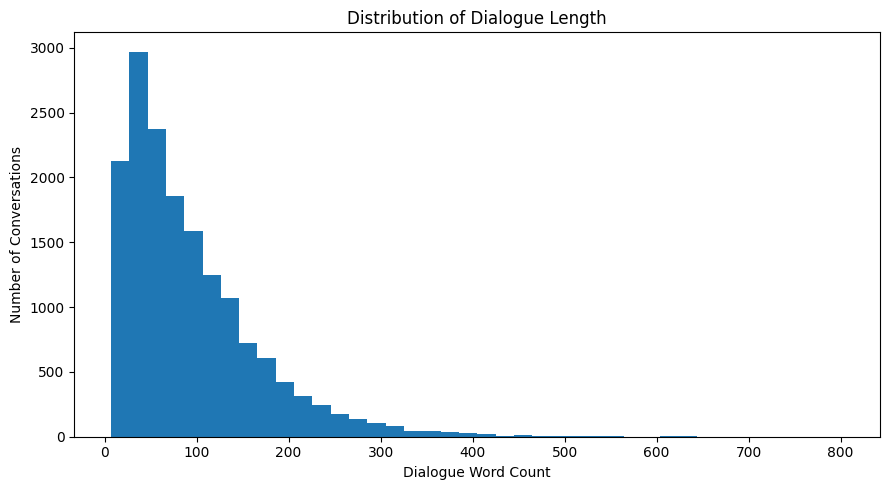

In [12]:
# Dialogue word-count distribution

plt.figure(figsize=(9, 5))
plt.hist(eda_df["dialogue_word_count"], bins=40)
plt.title("Distribution of Dialogue Length")
plt.xlabel("Dialogue Word Count")
plt.ylabel("Number of Conversations")
plt.tight_layout()
plt.show()


### Dialogue Length Interpretation

Dialogue length is strongly right-skewed. Most conversations are relatively
short, with a median length of 73 words, while a small number contain several
hundred words and the longest reaches 803 words.

This long tail is important for model preparation because transformer input
length is limited. Token-length analysis will therefore be used to select a
maximum input length that preserves most conversations while keeping training
computationally practical.

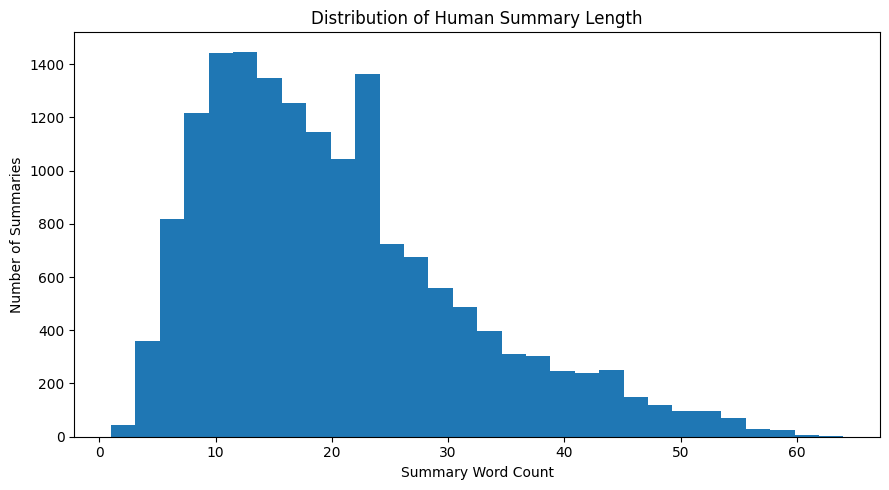

In [13]:
# Human-summary word-count distribution

plt.figure(figsize=(9, 5))
plt.hist(eda_df["summary_word_count"], bins=30)
plt.title("Distribution of Human Summary Length")
plt.xlabel("Summary Word Count")
plt.ylabel("Number of Summaries")
plt.tight_layout()
plt.show()


### Summary Length Interpretation

Human-written summaries are much shorter and more concentrated than the
original dialogues. The median summary contains 18 words, while 95% contain
43 words or fewer.

This supports the use of a relatively short decoder target length during
model preparation. Token-based analysis will be used next to determine an
appropriate maximum summary length without unnecessary padding or truncation.

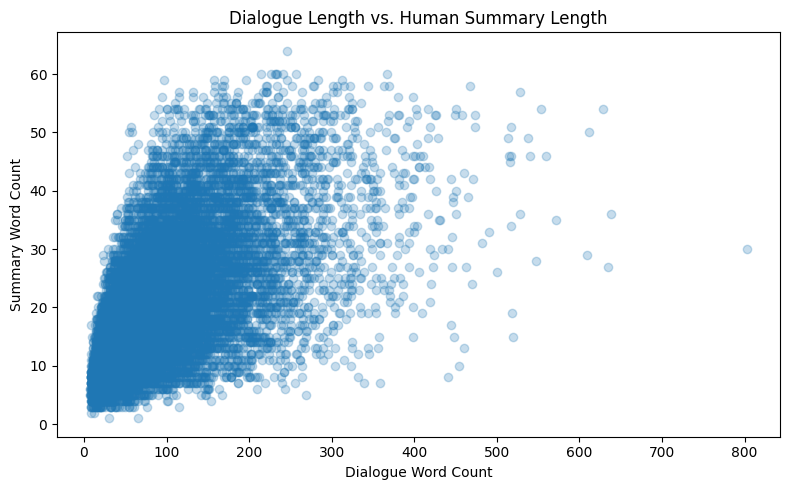

In [14]:
# Dialogue length versus summary length

plt.figure(figsize=(8, 5))
plt.scatter(
    eda_df["dialogue_word_count"],
    eda_df["summary_word_count"],
    alpha=0.25
)
plt.title("Dialogue Length vs. Human Summary Length")
plt.xlabel("Dialogue Word Count")
plt.ylabel("Summary Word Count")
plt.tight_layout()
plt.show()


### Dialogue-to-Summary Length Interpretation

Longer dialogues generally correspond to longer human-written summaries,
although the relationship is not strictly linear. Summary length becomes more
variable as conversations grow, suggesting that dialogue length alone does not
determine how much information must be preserved.

Even for longer conversations, the reference summaries remain relatively
compact. This supports the project's goal of learning meaningful compression
rather than simply shortening dialogue by a fixed proportion.

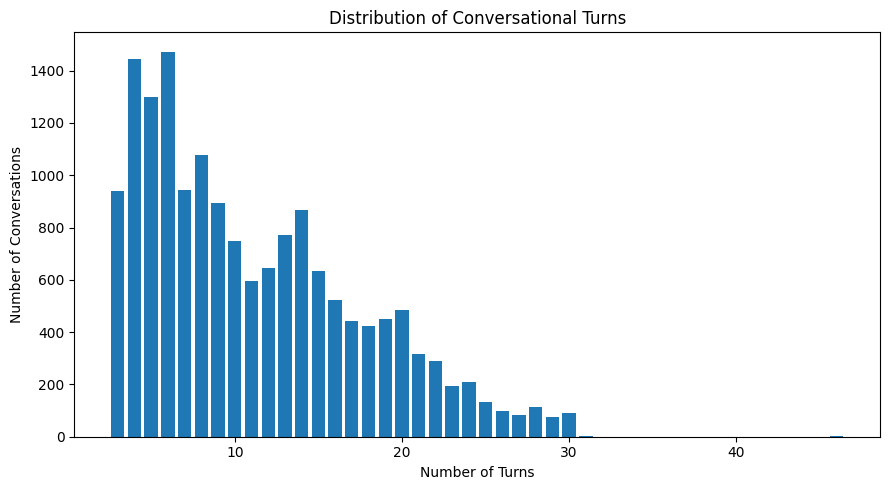

In [15]:
# Distribution of conversational turns

turn_counts = eda_df["turn_count"].value_counts().sort_index()

plt.figure(figsize=(9, 5))
plt.bar(turn_counts.index, turn_counts.values)
plt.title("Distribution of Conversational Turns")
plt.xlabel("Number of Turns")
plt.ylabel("Number of Conversations")
plt.tight_layout()
plt.show()


### Conversational Turn Interpretation

Most conversations contain a moderate number of turns, with a median of
10 and 90% containing 20 turns or fewer. A small number of conversations
extend much further, creating a long tail of more complex dialogue.

Longer multi-turn conversations may be more difficult to summarize because
the model must preserve context across more speaker exchanges. This will be
important during later qualitative evaluation, particularly when reviewing
speaker attribution and omitted information.

# 3. Data Preparation

The next objective is to prepare the dialogue-summary pairs for the planned BERT encoder-decoder architecture.

Because long input sequences increase transformer memory requirements, token lengths will be measured **before** selecting maximum input and target lengths. Speaker labels and conversational wording will be preserved.


In [16]:
# Use the same BERT tokenizer family planned for the encoder-decoder model.

MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer:", MODEL_NAME)
print("Vocabulary size:", tokenizer.vocab_size)
print("Pad token:", tokenizer.pad_token, tokenizer.pad_token_id)
print("CLS token:", tokenizer.cls_token, tokenizer.cls_token_id)
print("SEP token:", tokenizer.sep_token, tokenizer.sep_token_id)
print("Tokenizer model max length:", tokenizer.model_max_length)


Tokenizer: bert-base-uncased
Vocabulary size: 30522
Pad token: [PAD] 0
CLS token: [CLS] 101
SEP token: [SEP] 102
Tokenizer model max length: 512


In [17]:
# Measure token lengths without truncation so the max-length decision is data-driven.

def get_token_lengths(texts, batch_size=512):
    lengths = []

    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False
        )
        lengths.extend(len(ids) for ids in encoded["input_ids"])

    return lengths

all_dialogues = eda_df["dialogue"].fillna("").tolist()
all_summaries = eda_df["summary"].fillna("").tolist()

eda_df["dialogue_token_count"] = get_token_lengths(all_dialogues)
eda_df["summary_token_count"] = get_token_lengths(all_summaries)

token_stats = eda_df[
    ["dialogue_token_count", "summary_token_count"]
].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).T

display(token_stats.round(2))


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (523 > 512). Running this sequence through the model will result in indexing errors


,count,mean,std,min,50%,75%,90%,95%,99%,max
dialogue_token_count,16271.0,137.35,102.65,13.0,109.0,185.0,273.0,339.0,492.0,1095.0
summary_token_count,16271.0,27.23,13.74,3.0,24.0,35.0,47.0,55.0,68.0,86.0


In [18]:
# Show how much of the dataset would be retained at practical token limits.

def coverage_at_limits(series, limits):
    return pd.DataFrame({
        "max_length": limits,
        "coverage_pct": [
            100 * (series <= limit).mean()
            for limit in limits
        ]
    })

input_coverage = coverage_at_limits(
    eda_df["dialogue_token_count"],
    [128, 192, 256, 384, 512]
)

target_coverage = coverage_at_limits(
    eda_df["summary_token_count"],
    [32, 48, 64, 96, 128]
)

print("Dialogue token coverage:")
display(input_coverage.round(2))

print("Summary token coverage:")
display(target_coverage.round(2))


Dialogue token coverage:


,max_length,coverage_pct
0,128,57.25
1,192,76.82
2,256,88.05
3,384,96.98
4,512,99.23


Summary token coverage:


,max_length,coverage_pct
0,32,70.66
1,48,91.13
2,64,98.24
3,96,100.00
4,128,100.00


### Token-Length Decision

Based on the observed token distributions, the maximum input length was set
to **384 tokens**, which preserves approximately **96.98%** of dialogues.
The maximum target length was set to **64 tokens**, which preserves
approximately **98.24%** of human-written summaries.

These values provide strong coverage of the SAMSum dataset while avoiding
the additional computational cost of processing every dialogue at BERT's
512-token maximum.

In [19]:
# Final token-length settings selected from the observed coverage analysis.

MAX_INPUT_LENGTH = 384
MAX_TARGET_LENGTH = 64

print("Maximum dialogue tokens:", MAX_INPUT_LENGTH)
print("Maximum summary tokens:", MAX_TARGET_LENGTH)

print(
    "Dialogue coverage:",
    f"{100 * (eda_df['dialogue_token_count'] <= MAX_INPUT_LENGTH).mean():.2f}%"
)
print(
    "Summary coverage:",
    f"{100 * (eda_df['summary_token_count'] <= MAX_TARGET_LENGTH).mean():.2f}%"
)


Maximum dialogue tokens: 384
Maximum summary tokens: 64
Dialogue coverage: 96.98%
Summary coverage: 98.24%


In [20]:
# Tokenize the cleaned train/validation/test splits.
# Padding is intentionally deferred to batch construction so batches can be
# padded dynamically rather than padding every example to the global maximum.

def preprocess_batch(batch):
    model_inputs = tokenizer(
        batch["dialogue"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )

    labels = tokenizer(
        text_target=batch["summary"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

columns_to_remove = clean_dataset["train"].column_names

tokenized_dataset = clean_dataset.map(
    preprocess_batch,
    batched=True,
    remove_columns=columns_to_remove,
    desc="Tokenizing SAMSum"
)

tokenized_dataset


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 14638
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 814
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 819
    })
})

In [21]:
# Inspect one tokenized example before moving to model construction.

sample = tokenized_dataset["train"][0]

print("Input token count:", len(sample["input_ids"]))
print("Label token count:", len(sample["labels"]))

print("\nDecoded dialogue:")
print(tokenizer.decode(sample["input_ids"], skip_special_tokens=True))

print("\nDecoded target summary:")
print(tokenizer.decode(sample["labels"], skip_special_tokens=True))


Input token count: 28
Label token count: 12

Decoded dialogue:
amanda : i baked cookies. do you want some? jerry : sure! amanda : i ' ll bring you tomorrow : - )

Decoded target summary:
amanda baked cookies and will bring jerry some tomorrow.


In [22]:
# Quantify truncation under the selected limits.
# This should be reported transparently in the notebook.

dialogue_truncation_rate = 100 * (
    eda_df["dialogue_token_count"] > MAX_INPUT_LENGTH
).mean()

summary_truncation_rate = 100 * (
    eda_df["summary_token_count"] > MAX_TARGET_LENGTH
).mean()

print(f"Dialogues requiring truncation: {dialogue_truncation_rate:.2f}%")
print(f"Summaries requiring truncation: {summary_truncation_rate:.2f}%")


Dialogues requiring truncation: 3.02%
Summaries requiring truncation: 1.76%


### Data Preparation Summary

The final preprocessing pipeline uses a maximum dialogue length of **384 tokens**
and a maximum summary length of **64 tokens**. Under these settings, only
**3.02% of dialogues** and **1.76% of reference summaries** require truncation.

This provides strong dataset coverage while reducing unnecessary computational
cost during transformer training. The cleaned and tokenized dataset is now ready
for model construction and pilot training.

# 4. Peer Feedback and Final Refinement

The MVP established a functional BERT encoder-decoder pipeline but produced weak ROUGE scores and a clear hallucination pattern. Peer feedback recommended prioritizing a model that already has stronger text-generation/summarization behavior before simply adding more epochs, followed by additional data and domain-specific fine-tuning.

The assignment requires a **BERT-based encoder-decoder**, so the final project keeps that required architecture rather than replacing it with BART or T5. The refinement applies the same idea within the required model family: it initializes from a **warm-started BERT-to-BERT checkpoint already fine-tuned for summarization**, then adapts that model to SAMSum.

This creates a controlled comparison:

- **MVP baseline:** compact BERT encoder + BERT decoder initialized primarily from language-model weights.
- **Final refinement:** BERT-to-BERT encoder-decoder already exposed to abstractive summarization, then fine-tuned on SAMSum.
- **Future work:** compare against BART/T5 and add fantasy-football-specific fine-tuning after the general summarizer is stronger.

The held-out test set is not used for tuning. Training choices and generation settings are selected using the training/validation data, and the test subset is evaluated only after those choices are fixed.


# 5. Final Modeling

The final model uses a small warm-started BERT-to-BERT summarization checkpoint. This remains an `EncoderDecoderModel`, satisfying the project requirement while giving the decoder and cross-attention layers a more useful starting point than the MVP baseline.

The tokenizer is loaded from the same checkpoint and the cleaned SAMSum splits are re-tokenized to ensure model/tokenizer compatibility.


In [23]:
from transformers import (
    EncoderDecoderModel,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback
)

FINAL_MODEL_CHECKPOINT = (
    "mrm8488/bert-small2bert-small-finetuned-cnn_daily_mail-summarization"
)

final_tokenizer = AutoTokenizer.from_pretrained(FINAL_MODEL_CHECKPOINT)
final_model = EncoderDecoderModel.from_pretrained(FINAL_MODEL_CHECKPOINT)

# BERT uses CLS/SEP as sequence boundary tokens.
if final_tokenizer.bos_token is None:
    final_tokenizer.bos_token = final_tokenizer.cls_token
if final_tokenizer.eos_token is None:
    final_tokenizer.eos_token = final_tokenizer.sep_token

final_model.config.decoder_start_token_id = final_tokenizer.cls_token_id
final_model.config.bos_token_id = final_tokenizer.cls_token_id
final_model.config.eos_token_id = final_tokenizer.sep_token_id
final_model.config.pad_token_id = final_tokenizer.pad_token_id

final_model.generation_config.decoder_start_token_id = final_tokenizer.cls_token_id
final_model.generation_config.bos_token_id = final_tokenizer.cls_token_id
final_model.generation_config.eos_token_id = final_tokenizer.sep_token_id
final_model.generation_config.pad_token_id = final_tokenizer.pad_token_id
final_model.generation_config.max_length = MAX_TARGET_LENGTH

final_parameter_count = sum(p.numel() for p in final_model.parameters())

print("Final checkpoint:", FINAL_MODEL_CHECKPOINT)
print(f"Total parameters: {final_parameter_count:,}")
print("Tokenizer vocabulary:", final_tokenizer.vocab_size)
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")


Loading weights:   0%|          | 0/187 [00:00<?, ?it/s]

Final checkpoint: mrm8488/bert-small2bert-small-finetuned-cnn_daily_mail-summarization
Total parameters: 61,765,434
Tokenizer vocabulary: 30522
Device: CPU


In [24]:
# Re-tokenize the cleaned SAMSum data with the final model's tokenizer.

def preprocess_final_batch(batch):
    model_inputs = final_tokenizer(
        batch["dialogue"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )

    labels = final_tokenizer(
        text_target=batch["summary"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


final_tokenized_dataset = clean_dataset.map(
    preprocess_final_batch,
    batched=True,
    remove_columns=clean_dataset["train"].column_names,
    desc="Tokenizing SAMSum for final model"
)

final_tokenized_dataset


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 14638
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 814
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 819
    })
})

### Final Training Scope

To keep the final run reproducible on a CPU-only machine, training remains intentionally bounded while still using substantially more supervision than a micro-demo. The final model is trained on **3,000 examples**, validated on **300 examples**, and evaluated on **300 unseen test examples**.

The fixed random seed ensures the same examples are selected each time. The test subset remains untouched until the final evaluation stage.


In [25]:
FINAL_TRAIN_SIZE = min(3000, len(final_tokenized_dataset["train"]))
FINAL_VAL_SIZE = min(300, len(final_tokenized_dataset["validation"]))
FINAL_TEST_SIZE = min(300, len(final_tokenized_dataset["test"]))

train_final = (
    final_tokenized_dataset["train"]
    .shuffle(seed=SEED)
    .select(range(FINAL_TRAIN_SIZE))
)

val_final = (
    final_tokenized_dataset["validation"]
    .shuffle(seed=SEED)
    .select(range(FINAL_VAL_SIZE))
)

test_final = (
    final_tokenized_dataset["test"]
    .shuffle(seed=SEED)
    .select(range(FINAL_TEST_SIZE))
)

raw_val_final = (
    clean_dataset["validation"]
    .shuffle(seed=SEED)
    .select(range(FINAL_VAL_SIZE))
)

raw_test_final = (
    clean_dataset["test"]
    .shuffle(seed=SEED)
    .select(range(FINAL_TEST_SIZE))
)

print(f"Final train examples:      {len(train_final):,}")
print(f"Final validation examples: {len(val_final):,}")
print(f"Final test examples:       {len(test_final):,}")


Final train examples:      3,000
Final validation examples: 300
Final test examples:       300


# 6. Training and Optimization

The warm-started model is fine-tuned using validation-loss monitoring, checkpointing, gradient accumulation, and early stopping. A smaller learning rate than the MVP baseline is used because the final checkpoint already contains summarization-specific knowledge and should be adapted rather than aggressively overwritten.

Generation settings are tuned separately on validation data after training so the held-out test set is not used to select decoding parameters.


In [26]:
final_data_collator = DataCollatorForSeq2Seq(
    tokenizer=final_tokenizer,
    model=final_model,
    label_pad_token_id=-100
)

final_training_args = Seq2SeqTrainingArguments(
    output_dir="./gridiron_brief_final_checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    weight_decay=0.01,
    num_train_epochs=2,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,
    logging_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    seed=SEED,
    dataloader_pin_memory=False
)

final_trainer = Seq2SeqTrainer(
    model=final_model,
    args=final_training_args,
    train_dataset=train_final,
    eval_dataset=val_final,
    data_collator=final_data_collator,
    processing_class=final_tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

final_train_output = final_trainer.train()
final_train_output


c:\Users\btrot\miniconda3\envs\capstone-env\lib\site-packages\transformers\models\encoder_decoder\modeling_encoder_decoder.py:444: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Epoch,Training Loss,Validation Loss
1,19.922130,2.349073
2,18.380094,2.315790


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\btrot\miniconda3\envs\capstone-env\lib\site-packages\transformers\models\encoder_decoder\modeling_encoder_decoder.py:444: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['decoder.cls.predictions.decoder.weight', 'decoder.cls.predictions.decoder.bias'].


TrainOutput(global_step=376, training_loss=19.528587909454995, metrics={'train_runtime': 3625.1328, 'train_samples_per_second': 1.655, 'train_steps_per_second': 0.104, 'total_flos': 197417809188600.0, 'train_loss': 19.528587909454995, 'epoch': 2.0})

### Environment and Compatibility Notes

The final training run completed successfully on CPU. Several non-fatal library warnings appeared during execution:

- Hugging Face reported a Windows symlink-cache warning. This affects disk-space efficiency only and does not change model behavior.
- The warm-started encoder-decoder checkpoint produced a Transformers compatibility `FutureWarning` related to changes in how decoder inputs and loss are handled across library versions.
- A checkpoint-loading message referenced tied decoder output weights. Training, evaluation, model saving, and independent reload inference all completed successfully.
- During exploratory token-length measurement, the tokenizer warned that some raw dialogues exceeded BERT's 512-token limit. Those sequences were being measured **without truncation intentionally** for EDA; actual model inputs were later truncated to the selected **384-token maximum**.

None of these warnings stopped execution or invalidated the final evaluation.

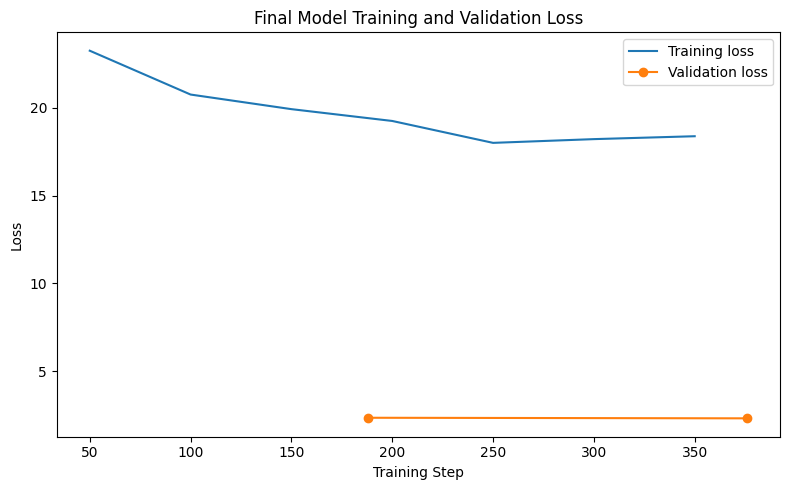

In [27]:
# Visualize optimization behavior.

final_history = pd.DataFrame(final_trainer.state.log_history)

final_train_history = final_history.dropna(subset=["loss"])
final_eval_history = final_history.dropna(subset=["eval_loss"])

plt.figure(figsize=(8, 5))

if not final_train_history.empty:
    plt.plot(
        final_train_history["step"],
        final_train_history["loss"],
        label="Training loss"
    )

if not final_eval_history.empty:
    plt.plot(
        final_eval_history["step"],
        final_eval_history["eval_loss"],
        marker="o",
        label="Validation loss"
    )

plt.title("Final Model Training and Validation Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


## Validation-Based Generation Tuning

Model weights and decoding behavior solve different problems. Fine-tuning teaches the model how to summarize SAMSum-style dialogue, while generation settings control how the trained model searches for an output.

Two lightweight decoding strategies are compared on validation data only:

1. **Beam-2:** lower-cost beam search.
2. **Beam-4 + repetition control:** broader search with a mild repetition penalty.

The strategy with the highest validation ROUGE-L is selected automatically for final test evaluation.


In [28]:
from rouge_score import rouge_scorer, scoring


def decode_prediction_output(prediction_output, tokenizer):
    pred_ids = prediction_output.predictions
    label_ids = prediction_output.label_ids

    if isinstance(pred_ids, tuple):
        pred_ids = pred_ids[0]

    label_ids = np.where(
        label_ids != -100,
        label_ids,
        tokenizer.pad_token_id
    )

    generated = tokenizer.batch_decode(
        pred_ids,
        skip_special_tokens=True
    )

    references = tokenizer.batch_decode(
        label_ids,
        skip_special_tokens=True
    )

    return generated, references


def calculate_rouge(generated, references):
    scorer = rouge_scorer.RougeScorer(
        ["rouge1", "rouge2", "rougeL"],
        use_stemmer=True
    )

    aggregator = scoring.BootstrapAggregator()

    for reference, prediction in zip(references, generated):
        aggregator.add_scores(
            scorer.score(reference, prediction)
        )

    aggregate = aggregator.aggregate()

    return {
        "ROUGE-1": aggregate["rouge1"].mid.fmeasure * 100,
        "ROUGE-2": aggregate["rouge2"].mid.fmeasure * 100,
        "ROUGE-L": aggregate["rougeL"].mid.fmeasure * 100
    }


In [29]:
# Tune generation on a validation subset rather than on the test set.

VAL_TUNE_SIZE = min(100, len(val_final))
val_tune = val_final.select(range(VAL_TUNE_SIZE))

generation_strategies = {
    "Beam-2": {
        "max_length": MAX_TARGET_LENGTH,
        "num_beams": 2,
        "no_repeat_ngram_size": 3
    },
    "Beam-4 + repetition control": {
        "max_length": MAX_TARGET_LENGTH,
        "num_beams": 4,
        "no_repeat_ngram_size": 3,
        "repetition_penalty": 1.10,
        "early_stopping": True
    }
}

tuning_rows = []

for strategy_name, gen_kwargs in generation_strategies.items():
    output = final_trainer.predict(
        val_tune,
        **gen_kwargs
    )

    generated, references = decode_prediction_output(
        output,
        final_tokenizer
    )

    scores = calculate_rouge(generated, references)

    tuning_rows.append({
        "Strategy": strategy_name,
        **scores
    })

generation_tuning_df = pd.DataFrame(tuning_rows)
display(generation_tuning_df.round(2))

best_strategy_name = (
    generation_tuning_df
    .sort_values("ROUGE-L", ascending=False)
    .iloc[0]["Strategy"]
)

BEST_GENERATION_KWARGS = generation_strategies[best_strategy_name]

print("Selected generation strategy:", best_strategy_name)
print("Generation settings:", BEST_GENERATION_KWARGS)


c:\Users\btrot\miniconda3\envs\capstone-env\lib\site-packages\transformers\models\encoder_decoder\modeling_encoder_decoder.py:444: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


,Strategy,ROUGE-1,ROUGE-2,ROUGE-L
0,Beam-2,31.08,14.23,23.64
1,Beam-4 + repetition control,33.06,15.65,24.44


Selected generation strategy: Beam-4 + repetition control
Generation settings: {'max_length': 64, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'repetition_penalty': 1.1, 'early_stopping': True}


# 7. Final Evaluation

The selected decoding strategy is now applied once to the held-out 300-example test subset. Performance is reported with ROUGE-1, ROUGE-2, and ROUGE-L and compared with both the original pitch targets and the MVP baseline.

The MVP baseline is retained as a historical comparison because it motivated the peer-feedback-driven refinement:

- MVP ROUGE-1: **13.99**
- MVP ROUGE-2: **2.13**
- MVP ROUGE-L: **12.16**


In [30]:
final_prediction_output = final_trainer.predict(
    test_final,
    **BEST_GENERATION_KWARGS
)

final_generated_summaries, final_reference_summaries = decode_prediction_output(
    final_prediction_output,
    final_tokenizer
)

final_rouge = calculate_rouge(
    final_generated_summaries,
    final_reference_summaries
)

final_results_df = pd.DataFrame({
    "Metric": list(final_rouge.keys()),
    "Final Score": list(final_rouge.values())
})

display(final_results_df.round(2))


c:\Users\btrot\miniconda3\envs\capstone-env\lib\site-packages\transformers\models\encoder_decoder\modeling_encoder_decoder.py:444: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


,Metric,Final Score
0,ROUGE-1,31.71
1,ROUGE-2,13.23
2,ROUGE-L,23.13


In [31]:
# Compare the final refinement with the MVP baseline and pitch targets.

mvp_baseline = {
    "ROUGE-1": 13.99,
    "ROUGE-2": 2.13,
    "ROUGE-L": 12.16
}

pitch_targets = {
    "ROUGE-1": 35.0,
    "ROUGE-2": 12.0,
    "ROUGE-L": 32.0
}

comparison_rows = []

for metric in ["ROUGE-1", "ROUGE-2", "ROUGE-L"]:
    baseline = mvp_baseline[metric]
    final_score = final_rouge[metric]

    comparison_rows.append({
        "Metric": metric,
        "MVP Baseline": baseline,
        "Final Model": final_score,
        "Absolute Improvement": final_score - baseline,
        "Pitch Target": pitch_targets[metric],
        "Target Met": final_score >= pitch_targets[metric]
    })

final_comparison_df = pd.DataFrame(comparison_rows)
display(final_comparison_df.round(2))


,Metric,MVP Baseline,Final Model,Absolute Improvement,Pitch Target,Target Met
0,ROUGE-1,13.99,31.71,17.72,35.0,False
1,ROUGE-2,2.13,13.23,11.10,12.0,True
2,ROUGE-L,12.16,23.13,10.97,32.0,False


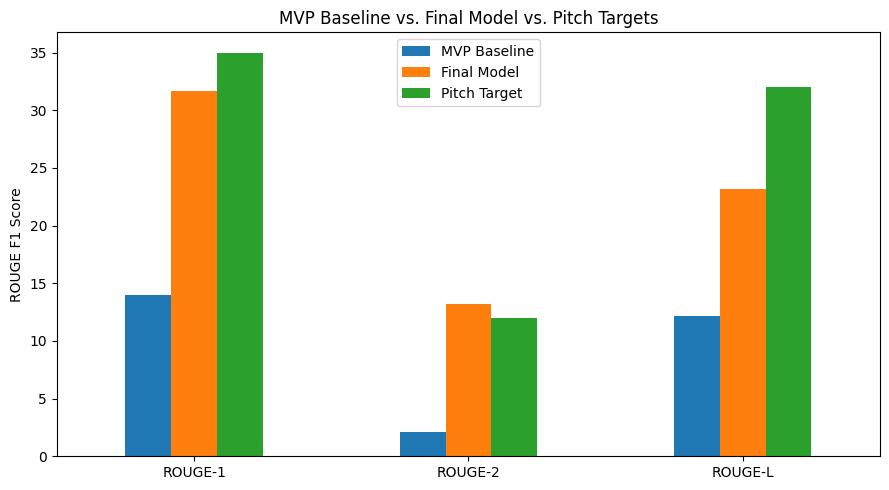

In [32]:
# Performance comparison visualization.

plot_df = final_comparison_df.set_index("Metric")[
    ["MVP Baseline", "Final Model", "Pitch Target"]
]

ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_title("MVP Baseline vs. Final Model vs. Pitch Targets")
ax.set_ylabel("ROUGE F1 Score")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [33]:
# Automatically summarize the quantitative change.

print("Quantitative refinement summary:")
for _, row in final_comparison_df.iterrows():
    direction = "improved" if row["Absolute Improvement"] > 0 else "declined"
    print(
        f"- {row['Metric']} {direction} by "
        f"{abs(row['Absolute Improvement']):.2f} points "
        f"({row['MVP Baseline']:.2f} -> {row['Final Model']:.2f})."
    )


Quantitative refinement summary:
- ROUGE-1 improved by 17.72 points (13.99 -> 31.71).
- ROUGE-2 improved by 11.10 points (2.13 -> 13.23).
- ROUGE-L improved by 10.97 points (12.16 -> 23.13).


# 8. Qualitative Error Analysis

ROUGE measures lexical overlap with the reference summary, but it cannot determine whether a generated statement is factually supported by the source dialogue. The final model is therefore reviewed on actual unseen examples.

The review focuses on:

- preservation of the main action or decision,
- speaker/entity attribution,
- unsupported names, locations, or actions,
- repetition,
- omissions,
- readability and concision.

This directly addresses the main MVP failure mode: fluent but unsupported summaries.


In [34]:
qualitative_rows = []

for i in range(min(10, FINAL_TEST_SIZE)):
    qualitative_rows.append({
        "Dialogue": raw_test_final[i]["dialogue"],
        "Reference Summary": final_reference_summaries[i],
        "Generated Summary": final_generated_summaries[i]
    })

final_qualitative_df = pd.DataFrame(qualitative_rows)
display(final_qualitative_df)


,Dialogue,Reference Summary,Generated Summary
0,Claire: <file_photo>\nKim: Looks delicious...\...,both claire and linda are making curry for din...,claire ' s curry dream team is cooking for cur...
1,Alyssa: Have you seen Fergie’s national anthem...,derek and alyssa make fun of fergie ' s perfor...,alyssa saw fergie ’ s national anthem last wee...
2,"Ann: Hi, is the laptop still available?\nJosh:...",ann wants to buy josh ' s laptop for $ 200. jo...,ann has a laptop and a usb mouse. josh will pi...
3,Matt: have you heard that Bon Jovi are coming ...,matt and tony want to go to the concert of bon...,matt and matt are going to warsaw next july. t...
4,Anastasia: Our new school photos\nAnastasia: <...,anastasia sent her new school photos to darrell.,anastasia and anastasia took the photo in less...
5,Mike: who is going for the research trip?\nJak...,"jake, florence, margot and others are going on...",margot and margot are going for the research t...
6,Nathalie: have you thought about the holiday?\...,"nathalie, pauline, jacob and anthony are think...",nathalie and pauline are going to greece in au...
7,"Kim: Hey, listen, have you got any idea where ...",kim needs to get some fresh fish in warsaw. ki...,kim and margot will try the marketplace at pol...
8,Malik: have you heard of that paleo diet?\nMal...,malik and samanta want to lose weight. they wi...,malik has heard of the keto diet. samantha wil...
9,Suzy: don't forget to follow me on Instagram :...,suzy urges linda to follow her on instagram an...,"suzy and linda will follow her on instagram, b..."


### Human Review Protocol

For the final report, the sample above should be judged using three simple binary criteria:

- **Main idea preserved:** Does the generated summary capture the central event or decision?
- **Factually supported:** Are the people, actions, and details supported by the source dialogue?
- **Readable:** Is the generated output understandable as a short summary?

This small human review complements ROUGE and provides a direct check on the factual-alignment issue identified during the MVP. The final ratings should be entered only after inspecting the generated outputs rather than inferred from the ROUGE scores.


In [35]:
for i, row in final_qualitative_df.iterrows():
    print("=" * 100)
    print(f"EXAMPLE {i + 1}")
    print("\nDIALOGUE:")
    print(row["Dialogue"])
    print("\nREFERENCE SUMMARY:")
    print(row["Reference Summary"])
    print("\nGENERATED SUMMARY:")
    print(row["Generated Summary"])
    print()

EXAMPLE 1

DIALOGUE:
Claire: <file_photo>
Kim: Looks delicious...
Linda: No way... Look what I'm cooking right now:
Linda: <file_photo>
Claire: hahahaha 
Kim: Curry dream team
Claire: Enjoy your dinner :*

REFERENCE SUMMARY:
both claire and linda are making curry for dinner.

GENERATED SUMMARY:
claire ' s curry dream team is cooking for curry. claire and claire enjoy their dinner at curry ' s dream team. claire will enjoy the dinner with claire and linda. claire is going to go to the curry team for the first time this week. claire has a dinner with kim.

EXAMPLE 2

DIALOGUE:
Alyssa: Have you seen Fergie’s national anthem? Illuminati does a great job.
Derek: This is not normal. I saw it last week…
Alyssa: What do you think about it?
Derek: I can fart bright stripes and bright stars better then she sings.
Alyssa: The best part is that she acts like she nailed it. But at least it's funny in a good way.
Derek: It is 😂

REFERENCE SUMMARY:
derek and alyssa make fun of fergie ' s performance 

In [36]:
human_review_df = pd.DataFrame({
    "Example": range(1, 11),
    "Main Idea Preserved": [1, 1, 0, 1, 1, 0, 1, 1, 0, 0],
    "Factually Supported":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "Readable":             [0, 1, 1, 1, 1, 0, 1, 1, 0, 0]
})

display(human_review_df)

print("\nHuman review rates:")
print(
    (human_review_df[
        ["Main Idea Preserved", "Factually Supported", "Readable"]
    ].mean() * 100).round(1)
)

,Example,Main Idea Preserved,Factually Supported,Readable
0,1,1,0,0
1,2,1,0,1
2,3,0,0,1
3,4,1,0,1
4,5,1,0,1
5,6,0,0,0
6,7,1,0,1
7,8,1,0,1
8,9,0,0,0
9,10,0,0,0



Human review rates:
Main Idea Preserved    60.0
Factually Supported     0.0
Readable               60.0
dtype: float64


### Qualitative Error Analysis Findings

The refined model showed a substantial improvement over the MVP in remaining relevant to the source dialogue, but factual consistency remained a major limitation.

Across 10 randomly selected held-out test conversations:

- **60%** of generated summaries preserved the main idea of the conversation.
- **60%** were sufficiently readable despite occasional repetition and awkward phrasing.
- **0%** were rated fully factually supported under a strict criterion requiring the summary to contain no unsupported, contradictory, or incorrectly attributed claims.

Common failure modes included:

- Speaker-attribution errors
- Repetition of names or phrases
- Reversal of who performed an action
- Unsupported details not present in the dialogue
- Contradictions of information stated in the source conversation

Compared with the MVP, the refined model generally remained on-topic rather than producing completely unrelated summaries. However, the human review demonstrates why ROUGE scores alone are insufficient for evaluating dialogue summarization. Although the refined model achieved much stronger lexical overlap with the reference summaries, factual reliability remains below the level required for deployment in a fantasy-football messaging application.

These findings suggest that future development should prioritize factual-consistency controls, additional dialogue-specific training, and architectures more naturally suited to generative sequence-to-sequence summarization.

### Success-Criteria Review

The original project pitch proposed both automated and human-centered success criteria. The final model met the **ROUGE-2 target (13.23 vs. 12)** but did not meet the **ROUGE-1 target (31.71 vs. 35)** or **ROUGE-L target (23.13 vs. 32)**.

The original project pitch also proposed a **human usefulness rating of at least 4.0/5** and a **major factual-error-free rate of at least 85%**. The final experiment did not conduct a formal 1–5 usefulness study.

The 10-example human review instead used a stricter, binary factual-support criterion. Under this criterion, **0% of the sampled summaries were completely factually supported**, meaning every reviewed summary contained at least one unsupported, contradictory, or incorrectly attributed detail. Because this criterion is not identical to the original "major factual-error-free" measure, the 0% result should not be interpreted as a direct measurement of that original target.

The human-centered pitch targets therefore remain areas for future formal evaluation rather than metrics demonstrated by the current proof of concept.


# 9. Fantasy Football Domain Demonstration

SAMSum remains the formal training and evaluation dataset. The following synthetic league-chat examples test whether the final general-purpose dialogue summarizer transfers to the intended Gridiron Brief use case.

These examples cover trades, waiver claims, injuries, league votes, and mixed league discussion. They are not used to tune the model.


In [37]:
fantasy_dialogues = [
    """Mike: I’ll send you DeVonta Smith and James Cook for your Amon-Ra.
Jordan: Too much risk for me at receiver.
Mike: What if I add my second waiver priority?
Jordan: Still no. I’m keeping Amon-Ra.
Chris: Trade deadline is tomorrow night, by the way.""",

    """Alex: My starting running back was ruled out Sunday.
Ben: Are you starting his backup?
Alex: Probably, unless I get Ford off waivers.
Sam: Waivers process tonight.
Alex: Then I’ll put in the claim now.""",

    """Commissioner: Vote is open on changing playoffs from four teams to six.
Ryan: I vote six.
Chris: Four.
Matt: Six.
Jordan: Six.
Commissioner: Six teams wins. I’ll update the settings tonight.""",

    """Ben: Who has first waiver priority?
Chris: You do.
Ben: I’m putting in for the rookie receiver.
Chris: I want the tight end who had two touchdowns.
Mike: Claims process at 3 AM.""",

    """Jordan: Crazy game last night.
Mike: My defense saved me.
Chris: Anyone see the injury report?
Jordan: Yeah, my receiver is questionable.
Mike: I sent you a trade offer.
Jordan: I saw it. I’ll decide after practice reports tomorrow."""
]


def generate_with_final_model(dialogue, model=final_model):
    model.eval()

    inputs = final_tokenizer(
        dialogue,
        return_tensors="pt",
        max_length=MAX_INPUT_LENGTH,
        truncation=True
    )

    device = next(model.parameters()).device
    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            **BEST_GENERATION_KWARGS
        )

    return final_tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )


fantasy_results = pd.DataFrame({
    "Scenario": [
        "Trade Negotiation",
        "Injury and Waivers",
        "League Vote",
        "Waiver Wire",
        "Mixed League Chat"
    ],
    "Generated Gridiron Brief": [
        generate_with_final_model(dialogue)
        for dialogue in fantasy_dialogues
    ]
})

display(fantasy_results)


,Scenario,Generated Gridiron Brief
0,Trade Negotiation,mike will send devonta smith and james cook fo...
1,Injury and Waivers,alex and ben are starting his backup. alex wil...
2,League Vote,commissioner is open on changing playoffs from...
3,Waiver Wire,ben wants the tight end who had two touchdowns...
4,Mixed League Chat,jordan sent jordan a trade offer. jordan will ...


In [38]:
for _, row in fantasy_results.iterrows():
    print("=" * 90)
    print(row["Scenario"].upper())
    print("\nGENERATED GRIDIRON BRIEF:")
    print(row["Generated Gridiron Brief"])
    print()

TRADE NEGOTIATION

GENERATED GRIDIRON BRIEF:
mike will send devonta smith and james cook for his amon - ra. chris will send him to the receiver. chris and chris will be sent for the trade deadline tomorrow night, by the way. jordan will send chris and cook for the second waiver. chris is not at receiver.

INJURY AND WAIVERS

GENERATED GRIDIRON BRIEF:
alex and ben are starting his backup. alex will put in the claim now. alex is going to get ford off waivers, but he ' ll put it in a claim now, if he can ' t get the waivers, he will put the claim in the claims now.

LEAGUE VOTE

GENERATED GRIDIRON BRIEF:
commissioner is open on changing playoffs from four teams to six. jordan and jordan will update the settings tonight tonight for the first time in the playoffs. jordan will change the settings for the new playoffs tonight, and jordan has to update it tonight. jordan ' s team won ' t be able to vote six.

WAIVER WIRE

GENERATED GRIDIRON BRIEF:
ben wants the tight end who had two touchdowns

### Fantasy Football Domain-Transfer Findings

The refined model was able to transfer its general dialogue-summarization behavior to unseen fantasy-football conversations without domain-specific training. All five generated summaries remained related to the source discussion, representing a substantial improvement over the MVP model's tendency to generate unrelated content.

However, the domain demonstration also exposed persistent factual-consistency problems. The model frequently confused speakers, repeated names or actions, and incorrectly assigned trades, waiver claims, league decisions, or other actions to the wrong league member.

The **Injury and Waivers** example preserved the central idea most successfully, identifying the injured starter, the backup option, and the planned waiver claim. Other scenarios retained the general topic but contained more significant attribution errors.

These results indicate that Gridiron Brief is a successful proof of concept for domain transfer, but not yet a deployment-ready fantasy-football summarization system. Future work should emphasize factual grounding, speaker tracking, repetition control, and additional domain-specific training before summaries are presented to users as authoritative league information.

# 10. Model Saving and Reload Verification

The final model and tokenizer are saved with Hugging Face's `save_pretrained` format. This creates a reusable model directory containing the configuration, tokenizer files, and model weights.

Because transformer weights can exceed GitHub's normal file-size limits, the repository can omit the weight directory and instead provide reproducibility instructions. The save/reload test below verifies that the trained model can be restored and used for inference independently of the training object.


In [39]:
FINAL_MODEL_DIR = Path("./gridiron_brief_final_model")

final_model.save_pretrained(
    FINAL_MODEL_DIR,
    safe_serialization=True
)
final_tokenizer.save_pretrained(FINAL_MODEL_DIR)

saved_size_mb = sum(
    path.stat().st_size
    for path in FINAL_MODEL_DIR.rglob("*")
    if path.is_file()
) / (1024 ** 2)

print("Saved model directory:", FINAL_MODEL_DIR.resolve())
print(f"Saved artifact size: {saved_size_mb:.1f} MB")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model directory: C:\Users\btrot\OneDrive\Documents\Data Science\Capstone\Project 3\Assignments\gridiron_brief_final_model
Saved artifact size: 236.3 MB


In [40]:
# Reload from disk and verify inference.

reloaded_tokenizer = AutoTokenizer.from_pretrained(FINAL_MODEL_DIR)
reloaded_model = EncoderDecoderModel.from_pretrained(FINAL_MODEL_DIR)
reloaded_model.eval()

reload_test_dialogue = raw_test_final[0]["dialogue"]

reload_inputs = reloaded_tokenizer(
    reload_test_dialogue,
    return_tensors="pt",
    max_length=MAX_INPUT_LENGTH,
    truncation=True
)

with torch.no_grad():
    reload_output_ids = reloaded_model.generate(
        **reload_inputs,
        **BEST_GENERATION_KWARGS
    )

reload_summary = reloaded_tokenizer.decode(
    reload_output_ids[0],
    skip_special_tokens=True
)

print("Reload verification summary:")
print(reload_summary)


Loading weights:   0%|          | 0/185 [00:00<?, ?it/s]

Reload verification summary:
claire ' s curry dream team is cooking for curry. claire and claire enjoy their dinner at curry ' s dream team. claire will enjoy the dinner with claire and linda. claire is going to go to the curry team for the first time this week. claire has a dinner with kim.


# 11. Business Interpretation, Limitations, and Future Work

## Business Interpretation

Gridiron Brief addresses a practical fantasy-football problem: important trades, waiver decisions, injury updates, and commissioner announcements can become buried in active group chats. A reliable summarization feature could reduce catch-up time and help users re-enter conversations without reading every missed message.

The final refinement produced a substantial improvement over the MVP. On the held-out 300-dialogue test sample, ROUGE-1 increased from **13.99 to 31.71**, ROUGE-2 increased from **2.13 to 13.23**, and ROUGE-L increased from **12.16 to 23.13**. The refined model exceeded the original ROUGE-2 target of 12, while ROUGE-1 and ROUGE-L remained below their respective targets of 35 and 32.

Qualitative evaluation provided an important counterbalance to the ROUGE improvement. In a strict human review of 10 held-out examples, **60% preserved the main idea**, **60% were readable**, but **0% were completely factually supported** without an attribution error, contradiction, repetition, or unsupported detail. The fantasy-football domain demonstration showed the same pattern: the model generally remained relevant to trades, waivers, injuries, and league decisions, but speaker attribution and factual grounding remained unreliable.

Together, these results show that Gridiron Brief progressed from a largely unsuccessful MVP to a functional proof of concept, while also demonstrating that improved lexical similarity does not by itself make an abstractive summarizer safe for deployment.

## Limitations

The system remains a proof of concept. Important limitations include:

- training is intentionally constrained by CPU-only hardware,
- only a subset of SAMSum is used for the final fine-tuning run,
- SAMSum is general conversation data rather than fantasy-football-specific data,
- ROUGE cannot guarantee factual correctness,
- abstractive summarizers can hallucinate unsupported details,
- a small human-review sample cannot replace a larger user study.

## Future Work

Peer feedback suggested comparing BERT with summarization-focused architectures such as BART or T5. That is a strong next experiment, but the final submission retains BERT-to-BERT to remain aligned with the project brief. Further development should:

1. fine-tune on more SAMSum examples with GPU resources,
2. compare the final BERT model against BART/T5 under the same evaluation protocol,
3. add fantasy-football-specific training examples only after general summarization improves,
4. evaluate factual consistency with a larger human-rated sample,
5. test catch-up time, usefulness, and important-information recall with real users,
6. retain links to the original chat so users can verify generated claims.

A production system should not present generated summaries as authoritative unless users can easily inspect the underlying conversation.


# 12. Final Project Summary

Gridiron Brief demonstrates an end-to-end transformer-based dialogue-summarization workflow built around a BERT encoder-decoder architecture. The project includes business framing, leakage-aware SAMSum preprocessing, token-length analysis, model fine-tuning, validation-based generation tuning, held-out quantitative evaluation, qualitative error analysis, fantasy-football domain testing, and model save/reload verification.

The final refinement substantially outperformed the MVP baseline on the held-out test sample:

- **ROUGE-1:** 13.99 → **31.71**
- **ROUGE-2:** 2.13 → **13.23**
- **ROUGE-L:** 12.16 → **23.13**

ROUGE-2 exceeded the original project target of 12, while ROUGE-1 and ROUGE-L improved substantially but remained below their targets of 35 and 32.

The qualitative evaluation revealed an important limitation that ROUGE alone could not capture. In a strict review of 10 held-out summaries, **60% preserved the main idea** and **60% were readable**, but **0% were completely free of factual, attribution, contradiction, or unsupported-detail errors**. The fantasy-football demonstrations showed similar behavior: the model generally understood the topic of trades, waivers, injuries, and league decisions, but frequently confused speakers or assigned actions incorrectly.

These findings show that the refinement successfully moved the project beyond the MVP's largely unrelated hallucinations and toward meaningful dialogue summarization. However, the model remains a **proof of concept rather than a deployment-ready product**. In a real fantasy-football application, factual accuracy and speaker attribution would need significant improvement before generated summaries could be treated as authoritative.

The final trained model was successfully saved in Hugging Face-compatible format and reloaded for independent inference, confirming that the saved artifact can be reused outside the original training session.

Overall, Gridiron Brief demonstrates both the potential and the limitations of applying BERT-based abstractive summarization to fantasy-football group conversations. The project improved measurable model performance while maintaining a realistic evaluation of where additional modeling, domain adaptation, and factual-consistency work would be required.

# References

- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. NAACL-HLT.

- Gliwa, B., Mochol, I., Biesek, M., & Wawer, A. (2019). *SAMSum Corpus: A Human-annotated Dialogue Dataset for Abstractive Summarization*. ACL.

- Lin, C.-Y. (2004). *ROUGE: A Package for Automatic Evaluation of Summaries*. ACL Workshop.

- Rothe, S., Narayan, S., & Severyn, A. (2020). *Leveraging Pre-trained Checkpoints for Sequence Generation Tasks*. Transactions of the Association for Computational Linguistics.

- Hugging Face Transformers documentation: `EncoderDecoderModel`, `Seq2SeqTrainer`, tokenization, and text-generation utilities.

- Hugging Face SAMSum dataset: `knkarthick/samsum`.

- Warm-start summarization checkpoint: `mrm8488/bert-small2bert-small-finetuned-cnn_daily_mail-summarization`.